# Checkpoint 4 -- ASR: Model Comparison

**Task:** Automatic Speech Recognition

**Candidates:**
- Whisper Tiny (`openai/whisper-tiny`, 39M) lower bound baseline
- Whisper Large-v3 Turbo (`openai/whisper-large-v3-turbo`, 809M)
- Whisper Large-v3 (`openai/whisper-large-v3`, 1.55B)
- Parakeet-TDT-0.6B-v3 (`nvidia/parakeet-tdt-0.6b-v3`, 600M) requires NVIDIA NeMo

**Datasets:** LibriSpeech test-clean (EN), FLEURS ru_ru test (RU)

**Metrics:** WER (primary), CER (secondary), RTFx (deployment)


## 0. Setup

In [2]:
!pip install  datasets==3.6.0
!pip install jiwer

In [3]:
import random
import re
import time
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import librosa
from datasets import load_dataset
from transformers import pipeline, AutoModelForSpeechSeq2Seq, AutoProcessor, WhisperForConditionalGeneration, WhisperProcessor
from jiwer import wer, cer
from tqdm.auto import tqdm
import soundfile as sf
import tempfile
import subprocess, sys

SEED = 31122002
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [4]:
TARGET_SR = 16_000
RESULTS_DIR = Path("results/asr")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

In [5]:
DEVICE

'cuda'

## 1. Metrics

### 1.1 WER (Word Error Rate) -- primary

WER = (S + D + I) / N

where S = substitutions, D = deletions, I = insertions, N = total reference words.

WER is the standard metric across all ASR benchmarks used in this work.

### 1.2 CER (Character Error Rate) -- secondary

Same edit-distance formula applied at character level.
CER is especially relevant for Russian dataset because single wrong letter in suffix or prefix may change whole word meaning.

### 1.3 RTFx (Real-Time Factor, inverse) -- deployment metric

RTFx = AD / PT

where AD = total audio duration (seconds), PT = total processing time (seconds).
RTFx > 1 means faster than real-time.

**Important:** RTFx values in this notebook are measured on the actual runtime hardware
(Using Nvidia A100 GPU in colab).

In [6]:
def normalize_text(text, yo_to_ye = False):
    """
    Normalize transcript for WER or CER scoring.
    """
    text = unicodedata.normalize("NFC", text)
    text = text.lower()
    if yo_to_ye:
        text = text.replace("\u0451", "\u0435")

    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def detect_yo_normalization(hypotheses, references):
    yo_char = "\u0451"
    ref_yo = sum(yo_char in r for r in references)
    hyp_yo = sum(yo_char in h for h in hypotheses)
    if ref_yo == 0:
        return False
    return (hyp_yo / ref_yo) < 0.1

## 2. Datasets

The preprocessing logic is same as in EDA: 16kHz, mono, float32.

In [7]:
ls_test = load_dataset(
    "openslr/librispeech_asr",
    "clean",
    split="test",
    trust_remote_code=True,
)
print(len(ls_test))
print(ls_test.features)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

2620
{'file': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'text': Value(dtype='string', id=None), 'speaker_id': Value(dtype='int64', id=None), 'chapter_id': Value(dtype='int64', id=None), 'id': Value(dtype='string', id=None)}


In [8]:
fl_test = load_dataset(
    "google/fleurs",
    "ru_ru",
    split="test",
    trust_remote_code=True,
)
print(len(fl_test))
print(fl_test.features)

775
{'id': Value(dtype='int32', id=None), 'num_samples': Value(dtype='int32', id=None), 'path': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'transcription': Value(dtype='string', id=None), 'raw_transcription': Value(dtype='string', id=None), 'gender': ClassLabel(names=['male', 'female', 'other'], id=None), 'lang_id': ClassLabel(names=['af_za', 'am_et', 'ar_eg', 'as_in', 'ast_es', 'az_az', 'be_by', 'bg_bg', 'bn_in', 'bs_ba', 'ca_es', 'ceb_ph', 'ckb_iq', 'cmn_hans_cn', 'cs_cz', 'cy_gb', 'da_dk', 'de_de', 'el_gr', 'en_us', 'es_419', 'et_ee', 'fa_ir', 'ff_sn', 'fi_fi', 'fil_ph', 'fr_fr', 'ga_ie', 'gl_es', 'gu_in', 'ha_ng', 'he_il', 'hi_in', 'hr_hr', 'hu_hu', 'hy_am', 'id_id', 'ig_ng', 'is_is', 'it_it', 'ja_jp', 'jv_id', 'ka_ge', 'kam_ke', 'kea_cv', 'kk_kz', 'km_kh', 'kn_in', 'ko_kr', 'ky_kg', 'lb_lu', 'lg_ug', 'ln_cd', 'lo_la', 'lt_lt', 'luo_ke', 'lv_lv', 'mi_nz', 'mk_mk', 'ml_in', 'mn_mn', 'mr_in', 'ms_my', 'mt_mt', 'my_mm', 'nb_no

In [9]:
def get_audio(sample, dataset_name):
    """Extract float32 array resampled to 16kHz."""
    arr = np.array(sample["audio"]["array"], dtype=np.float32)
    sr = sample["audio"]["sampling_rate"]
    if sr != TARGET_SR:
        arr = librosa.resample(arr, orig_sr=sr, target_sr=TARGET_SR)
    return arr


def get_reference(sample, dataset_name):
    if dataset_name == "librispeech":
        return sample["text"]
    if dataset_name == "fleurs":
        return sample["transcription"]
    raise ValueError(f"Unknown ds: {dataset_name}")

## 3. Evaluation Pipeline

Batch size is set to 16 for GPU, Measured on Nvidia A100

In [10]:
def load_whisper(model_id: str):
    processor = WhisperProcessor.from_pretrained(model_id)
    model = WhisperForConditionalGeneration.from_pretrained(
        model_id, torch_dtype=DTYPE
    )
    model.to(DEVICE)
    model.eval()
    print(f"Loaded: {model_id}")
    return processor, model

In [14]:
def evaluate_model_batch(
    processor,
    model,
    dataset,
    dataset_name: str,
    language: str,
    model_name: str,
    batch_size: int = 16,
    yo_to_ye: bool = False,
) -> tuple:
    rows = []
    total_audio_sec = 0.0
    total_wall_sec = 0.0

    forced_decoder_ids = processor.get_decoder_prompt_ids(
        language=language, task="transcribe"
    )

    batch_arrays = []
    batch_refs = []
    batch_durations = []

    def process_batch(arrays, refs, durations):
        nonlocal total_audio_sec, total_wall_sec

        inputs = processor(
            arrays,
            sampling_rate=TARGET_SR,
            return_tensors="pt",
            padding=True,
        )
        input_features = inputs.input_features.to(DEVICE, dtype=DTYPE)

        t0 = time.perf_counter()
        with torch.no_grad():
            predicted_ids = model.generate(
                input_features,
                forced_decoder_ids=forced_decoder_ids,
            )
        total_wall_sec += time.perf_counter() - t0
        total_audio_sec += sum(durations)

        hypotheses = processor.batch_decode(
            predicted_ids, skip_special_tokens=True
        )

        for ref_raw, hyp_raw, dur in zip(refs, hypotheses, durations):
            ref = normalize_text(ref_raw, yo_to_ye=yo_to_ye)
            hyp = normalize_text(hyp_raw, yo_to_ye=yo_to_ye)

            try:
                s_wer = wer(ref, hyp) if ref.strip() else float("nan")
                s_cer = cer(ref, hyp) if ref.strip() else float("nan")
            except Exception:
                s_wer, s_cer = float("nan"), float("nan")

            rows.append({
                "ref": ref,
                "hyp": hyp,
                "wer": round(s_wer, 4),
                "cer": round(s_cer, 4),
                "duration_sec": round(dur, 3),
                "n_ref_words": len(ref.split()),
            })

    for sample in tqdm(dataset, desc=f"{model_name} / {dataset_name}"):
        arr = get_audio(sample, dataset_name)
        ref_raw = get_reference(sample, dataset_name)
        duration = len(arr) / TARGET_SR

        batch_arrays.append(arr)
        batch_refs.append(ref_raw)
        batch_durations.append(duration)

        if len(batch_arrays) == batch_size:
            process_batch(batch_arrays, batch_refs, batch_durations)
            batch_arrays, batch_refs, batch_durations = [], [], []

    if batch_arrays:
        process_batch(batch_arrays, batch_refs, batch_durations)

    df = pd.DataFrame(rows)
    all_refs = df["ref"].tolist()
    all_hyps = df["hyp"].tolist()
    corpus_wer = wer(all_refs, all_hyps)
    corpus_cer = cer(all_refs, all_hyps)
    rtfx = total_audio_sec / total_wall_sec if total_wall_sec > 0 else float("nan")

    summary = {
        "model": model_name,
        "dataset": dataset_name,
        "n_samples": len(df),
        "corpus_wer": round(corpus_wer, 4),
        "corpus_cer": round(corpus_cer, 4),
        "rtfx": round(rtfx, 2),
        "total_audio_h": round(total_audio_sec / 3600, 3),
        "yo_to_ye": yo_to_ye,
    }

    print(f"\n{model_name} | {dataset_name}")
    print(f"Corpus WER: {corpus_wer*100:.2f}%")
    print(f"Corpus CER: {corpus_cer*100:.2f}%")
    print(f"RTFx: {rtfx:.1f}x  (measured on {DEVICE}, batch_size={batch_size})")

    return df, summary

## 4. Candidate 1: Whisper Tiny

Lower bound baseline (39M parameters).
Expected WER on LibriSpeech test-clean: approximately 6-8%.


In [15]:
processor_tiny, model_tiny = load_whisper("openai/whisper-tiny")

Loaded: openai/whisper-tiny


In [17]:
df_tiny_ls, s_tiny_ls = evaluate_model_batch(
    processor_tiny, model_tiny,
    ls_test, "librispeech", "english", "Whisper-Tiny",
    batch_size=16,
)
df_tiny_ls.to_csv(RESULTS_DIR / "tiny_librispeech.csv", index=False)

Whisper-Tiny / librispeech:   0%|          | 0/2620 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Whisper-Tiny | librispeech
  Corpus WER : 8.13%
  Corpus CER : 3.37%
  RTFx       : 348.8x  (measured on cuda, batch_size=16)


In [18]:
df_tiny_fl, s_tiny_fl = evaluate_model_batch(
    processor_tiny, model_tiny,
    fl_test, "fleurs", "russian", "Whisper-Tiny"
)
df_tiny_fl.to_csv(RESULTS_DIR / "tiny_fleurs_ru.csv", index=False)

Whisper-Tiny / fleurs:   0%|          | 0/775 [00:00<?, ?it/s]


Whisper-Tiny | fleurs
  Corpus WER : 38.86%
  Corpus CER : 11.92%
  RTFx       : 317.2x  (measured on cuda, batch_size=16)


In [19]:
del model_tiny, processor_tiny
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("Whisper Tiny unloaded")

Whisper Tiny unloaded


## 5. Candidate 2: Whisper Large-v3 Turbo

809M parameters. Decoder reduced from 32 to 4 layers compared to Large-v3.
Published RTFx on A100: 121.11. Published WER EN: 6.4%.


In [20]:
processor_turbo, model_turbo = load_whisper("openai/whisper-large-v3-turbo")

Loaded: openai/whisper-large-v3-turbo


In [21]:
df_turbo_ls, s_turbo_ls = evaluate_model_batch(
    processor_turbo, model_turbo, ls_test, "librispeech", "english", "Whisper-Turbo",
    batch_size=16,
)
df_turbo_ls.to_csv(RESULTS_DIR / "turbo_librispeech.csv", index=False)

Whisper-Turbo / librispeech:   0%|          | 0/2620 [00:00<?, ?it/s]


Whisper-Turbo | librispeech
  Corpus WER : 3.08%
  Corpus CER : 1.22%
  RTFx       : 195.8x  (measured on cuda, batch_size=16)


In [22]:
df_turbo_fl, s_turbo_fl = evaluate_model_batch(
    processor_turbo, model_turbo, fl_test, "fleurs", "russian", "Whisper-Turbo",
    batch_size=16,
)
df_turbo_fl.to_csv(RESULTS_DIR / "turbo_fleurs_ru.csv", index=False)

Whisper-Turbo / fleurs:   0%|          | 0/775 [00:00<?, ?it/s]


Whisper-Turbo | fleurs
  Corpus WER : 6.11%
  Corpus CER : 2.01%
  RTFx       : 236.2x  (measured on cuda, batch_size=16)


In [23]:
del processor_turbo, model_turbo
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("Whisper Turbo unloaded")

Whisper Turbo unloaded


## 6. Candidate 3: Whisper Large-v3

1.55B parameters. Maximum language coverage (99 languages).
Published RTFx on A100: 68.56. Published WER EN: 6.43%.
This model defines the quality upper bound in the Whisper family.


In [24]:
processor_large, model_large = load_whisper("openai/whisper-large-v3")

Loaded: openai/whisper-large-v3


In [25]:
df_large_ls, s_large_ls = evaluate_model_batch(
    processor_large, model_large, ls_test, "librispeech", "english", "Whisper-Large-v3",
    batch_size=16,
)
df_large_ls.to_csv(RESULTS_DIR / "large_librispeech.csv", index=False)

Whisper-Large-v3 / librispeech:   0%|          | 0/2620 [00:00<?, ?it/s]


Whisper-Large-v3 | librispeech
  Corpus WER : 2.82%
  Corpus CER : 1.01%
  RTFx       : 57.4x  (measured on cuda, batch_size=16)


In [26]:
df_large_fl, s_large_fl = evaluate_model_batch(
    processor_large, model_large, fl_test, "fleurs", "russian", "Whisper-Large-v3",
    batch_size=16,
)
df_large_fl.to_csv(RESULTS_DIR / "large_fleurs_ru.csv", index=False)

Whisper-Large-v3 / fleurs:   0%|          | 0/775 [00:00<?, ?it/s]


Whisper-Large-v3 | fleurs
  Corpus WER : 4.94%
  Corpus CER : 1.34%
  RTFx       : 62.3x  (measured on cuda, batch_size=16)


In [ ]:
del processor_large, model_large
if DEVICE == "cuda":
    torch.cuda.empty_cache()

## 7. Candidate 4: Parakeet-TDT-0.6B-v3

600M parameters. FastConformer encoder + TDT decoder.
Published RTFx on A100: 3332.74. Published WER EN: 6.34%.


In [1]:
!pip install nemo_toolkit[asr]==2.2.0

In [ ]:
import nemo.collections.asr as nemo_asr

In [45]:
if torch.cuda.is_available():
    MODEL_PARAKEET = "nvidia/parakeet-tdt-0.6b-v3"
    parakeet = nemo_asr.models.ASRModel.from_pretrained(MODEL_PARAKEET)
    parakeet = parakeet.cuda()
    parakeet.eval()
    print(f"Loaded: {MODEL_PARAKEET}")

[NeMo I 2026-04-06 10:46:38 nemo_logging:393] Tokenizer SentencePieceTokenizer initialized with 8192 tokens


[NeMo W 2026-04-06 10:46:42 nemo_logging:405] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    use_lhotse: true
    skip_missing_manifest_entries: true
    input_cfg: null
    tarred_audio_filepaths: null
    manifest_filepath: null
    sample_rate: 16000
    shuffle: true
    num_workers: 2
    pin_memory: true
    max_duration: 10.0
    min_duration: 1.0
    text_field: answer
    batch_duration: null
    max_tps: null
    use_bucketing: true
    bucket_duration_bins: null
    bucket_batch_size: null
    num_buckets: 30
    bucket_buffer_size: 20000
    shuffle_buffer_size: 10000
    
[NeMo W 2026-04-06 10:46:42 nemo_logging:405] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    V

[NeMo I 2026-04-06 10:46:42 nemo_logging:393] PADDING: 0
[NeMo I 2026-04-06 10:46:48 nemo_logging:393] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-04-06 10:46:48 nemo_logging:393] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-04-06 10:46:48 nemo_logging:393] Using RNNT Loss : tdt
    Loss tdt_kwargs: {'fastemit_lambda': 0.0, 'clamp': -1.0, 'durations': [0, 1, 2, 3, 4], 'sigma': 0.02, 'omega': 0.1}
[NeMo I 2026-04-06 10:46:50 nemo_logging:393] Model EncDecRNNTBPEModel was successfully restored from /root/.cache/huggingface/hub/models--nvidia--parakeet-tdt-0.6b-v3/snapshots/6d590f77001d318fb17a0b5bf7ee329a91b52598/parakeet-tdt-0.6b-v3.nemo.
Loaded: nvidia/parakeet-tdt-0.6b-v3


In [42]:
def evaluate_parakeet(
    model,
    dataset,
    dataset_name: str,
    model_name: str,
    batch_size: int = 16,
    yo_to_ye: bool = False,
) -> tuple:

    rows = []
    total_audio_sec = 0.0
    total_wall_sec = 0.0
    tmp_dir = Path(tempfile.mkdtemp())

    all_arrays = []
    all_refs = []
    all_durations = []
    all_paths = []

    print("Preparing audio files...")
    for i, sample in enumerate(tqdm(dataset, desc="writing wav")):
        arr = get_audio(sample, dataset_name)
        ref_raw = get_reference(sample, dataset_name)
        duration = len(arr) / TARGET_SR

        wav_path = str(tmp_dir / f"{i:05d}.wav")
        sf.write(wav_path, arr, TARGET_SR)

        all_arrays.append(arr)
        all_refs.append(ref_raw)
        all_durations.append(duration)
        all_paths.append(wav_path)


    all_hypotheses = []
    for start in tqdm(range(0, len(all_paths), batch_size), desc=f"{model_name}"):
        batch_paths = all_paths[start : start + batch_size]
        batch_dur   = all_durations[start : start + batch_size]

        t0 = time.perf_counter()
        results = model.transcribe(batch_paths, batch_size=batch_size)
        total_wall_sec += time.perf_counter() - t0
        total_audio_sec += sum(batch_dur)

        for r in results:
            hyp_raw = r if isinstance(r, str) else r.text
            all_hypotheses.append(hyp_raw)

    for ref_raw, hyp_raw, dur in zip(all_refs, all_hypotheses, all_durations):
        ref = normalize_text(ref_raw, yo_to_ye=yo_to_ye)
        hyp = normalize_text(hyp_raw, yo_to_ye=yo_to_ye)

        try:
            s_wer = wer(ref, hyp) if ref.strip() else float("nan")
            s_cer = cer(ref, hyp) if ref.strip() else float("nan")
        except Exception:
            s_wer, s_cer = float("nan"), float("nan")

        rows.append({
            "ref": ref,
            "hyp": hyp,
            "wer": round(s_wer, 4),
            "cer": round(s_cer, 4),
            "duration_sec": round(dur, 3),
            "n_ref_words": len(ref.split()),
        })

    df = pd.DataFrame(rows)
    corpus_wer = wer(df["ref"].tolist(), df["hyp"].tolist())
    corpus_cer = cer(df["ref"].tolist(), df["hyp"].tolist())
    rtfx = total_audio_sec / total_wall_sec if total_wall_sec > 0 else float("nan")

    summary = {
        "model": model_name,
        "dataset": dataset_name,
        "n_samples": len(df),
        "corpus_wer": round(corpus_wer, 4),
        "corpus_cer": round(corpus_cer, 4),
        "rtfx": round(rtfx, 2),
        "total_audio_h": round(total_audio_sec / 3600, 3),
        "yo_to_ye": yo_to_ye,
    }

    print(f"\n{model_name} | {dataset_name}")
    print(f"  Corpus WER : {corpus_wer*100:.2f}%")
    print(f"  Corpus CER : {corpus_cer*100:.2f}%")
    print(f"  RTFx       : {rtfx:.1f}x  (measured on {DEVICE}, batch_size={batch_size})")

    return df, summary

In [46]:
df_par_ls, s_par_ls = evaluate_parakeet(
    parakeet, ls_test, "librispeech", "Parakeet-TDT-0.6B-v3",
    batch_size=16,
)
df_par_ls.to_csv(RESULTS_DIR / "parakeet_librispeech.csv", index=False)

Preparing audio files...


writing wav:   0%|          | 0/2620 [00:00<?, ?it/s]

Running inference (batch_size=16)...


Parakeet-TDT-0.6B-v3:   0%|          | 0/164 [00:00<?, ?it/s]


Transcribing: 100%|██████████| 1/1 [00:00<00:00,  1.85it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.66it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  4.43it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.10it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.95it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.03it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.43it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.06it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  2.02it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.49it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  1.89it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.38it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  5.13it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  4.35it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  4.27it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  2.59it/s]

Transcribing: 100%|████


Parakeet-TDT-0.6B-v3 | librispeech
  Corpus WER : 2.10%
  Corpus CER : 0.61%
  RTFx       : 343.6x  (measured on cuda, batch_size=16)


In [48]:
df_par_fl, s_par_fl = evaluate_parakeet(
    parakeet, fl_test, "fleurs", "Parakeet-TDT-0.6B-v3",
    batch_size=16,
)
df_par_fl.to_csv(RESULTS_DIR / "parakeet_fleurs_ru.csv", index=False)

Preparing audio files...


writing wav:   0%|          | 0/775 [00:00<?, ?it/s]

Running inference (batch_size=16)...


Parakeet-TDT-0.6B-v3:   0%|          | 0/49 [00:00<?, ?it/s]


Transcribing: 100%|██████████| 1/1 [00:00<00:00,  1.82it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  1.66it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  2.97it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.02it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.57it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  2.66it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.79it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.43it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  2.57it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.25it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  2.27it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  2.74it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  3.62it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  2.84it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  2.27it/s]

Transcribing: 100%|██████████| 1/1 [00:00<00:00,  1.97it/s]

Transcribing: 100%|████


Parakeet-TDT-0.6B-v3 | fleurs
  Corpus WER : 6.72%
  Corpus CER : 1.73%
  RTFx       : 459.1x  (measured on cuda, batch_size=16)


## 8. Results

### 8.1 Summary table

In [49]:
all_summaries = [s_tiny_ls, s_tiny_fl, s_turbo_ls, s_turbo_fl,
                 s_large_ls, s_large_fl, s_par_ls, s_par_fl]

results_df = pd.DataFrame(all_summaries)
results_df["wer_pct"] = results_df["corpus_wer"].map(
    lambda x: f"{x*100:.2f}%" if x is not None else "n/a"
)
results_df["cer_pct"] = results_df["corpus_cer"].map(
    lambda x: f"{x*100:.2f}%" if x is not None else "n/a"
)
results_df["rtfx_str"] = results_df["rtfx"].map(
    lambda x: f"{x:.1f}x" if x is not None else "n/a"
)

display_cols = ["model", "dataset", "wer_pct", "cer_pct", "rtfx_str", "n_samples"]
print(results_df[display_cols].to_string(index=False))

results_df.to_csv(RESULTS_DIR / "summary_all_models.csv", index=False)

               model     dataset wer_pct cer_pct rtfx_str  n_samples
        Whisper-Tiny librispeech   8.13%   3.37%   348.8x       2620
        Whisper-Tiny      fleurs  38.86%  11.92%   317.2x        775
       Whisper-Turbo librispeech   3.08%   1.22%   195.8x       2620
       Whisper-Turbo      fleurs   6.11%   2.01%   236.2x        775
    Whisper-Large-v3 librispeech   2.82%   1.01%    57.4x       2620
    Whisper-Large-v3      fleurs   4.94%   1.34%    62.3x        775
Parakeet-TDT-0.6B-v3 librispeech   2.10%   0.61%   343.6x       2620
Parakeet-TDT-0.6B-v3      fleurs   6.72%   1.73%   459.1x        775


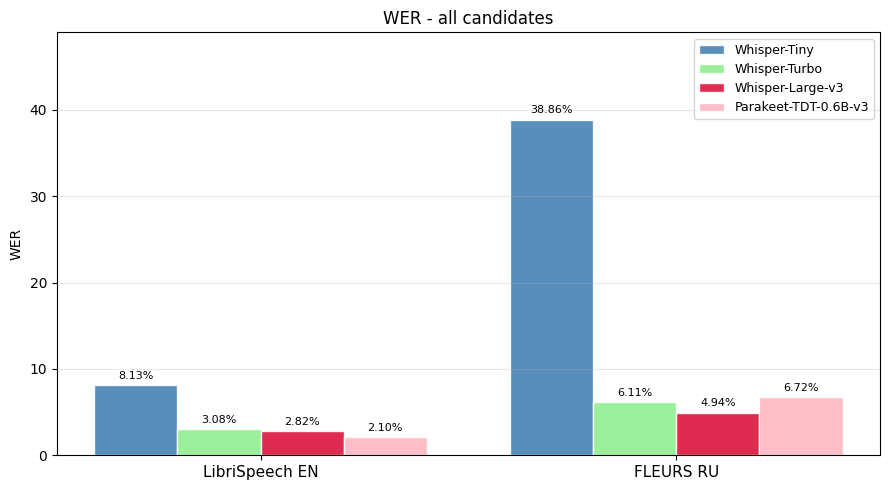

In [76]:
models_order = ["Whisper-Tiny", "Whisper-Turbo", "Whisper-Large-v3", "Parakeet-TDT-0.6B-v3"]
colors_map = {
    "Whisper-Tiny": "Steelblue",
    "Whisper-Turbo": "Lightgreen",
    "Whisper-Large-v3": "crimson",
    "Parakeet-TDT-0.6B-v3": "Lightpink",
}
dataset_keys = ["librispeech", "fleurs"]
dataset_labels = ["LibriSpeech EN", "FLEURS RU"]

x = np.arange(len(dataset_keys))
fig, ax = plt.subplots(figsize=(9, 5))

for i, model in enumerate(models_order):
    vals = []
    for ds in dataset_keys:
        row = results_df[(results_df["model"] == model) & (results_df["dataset"] == ds)]
        v = row["corpus_wer"].values[0] if len(row) and pd.notna(row["corpus_wer"].values[0]) else None
        vals.append(v * 100 if v is not None else 0)
    offset = (i - len(models_order) / 2 + 0.5) * 0.2
    bars = ax.bar(x + offset, vals, 0.2, label=model,
                  color=colors_map[model], edgecolor="white", alpha=0.9)
    ax.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=8)

ax.set_title("WER - all candidates", fontsize=12)
ax.set_ylabel("WER")
ax.set_xticks(x)
ax.set_xticklabels(dataset_labels, fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "chart_wer.png", dpi=150, bbox_inches="tight")
plt.show()

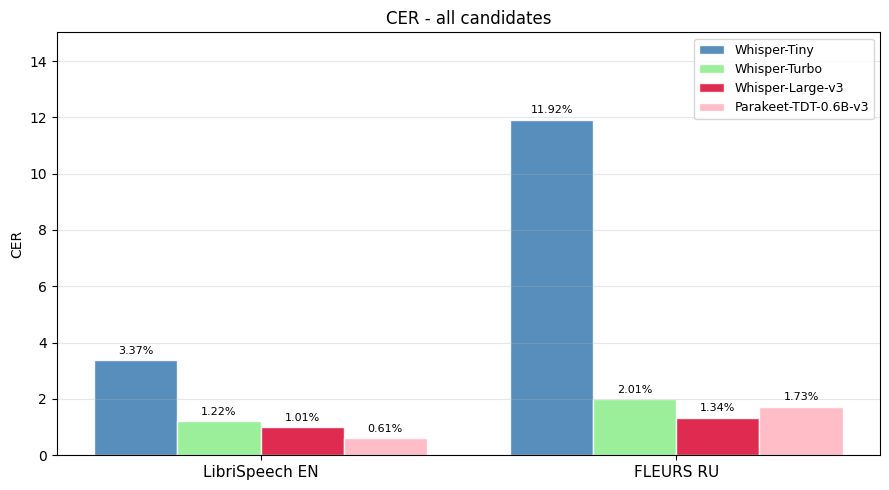

In [75]:
fig, ax = plt.subplots(figsize=(9, 5))

for i, model in enumerate(models_order):
    vals = []
    for ds in dataset_keys:
        row = results_df[(results_df["model"] == model) & (results_df["dataset"] == ds)]
        v = row["corpus_cer"].values[0] if len(row) and pd.notna(row["corpus_cer"].values[0]) else None
        vals.append(v * 100 if v is not None else 0)
    offset = (i - len(models_order) / 2 + 0.5) * 0.2
    bars = ax.bar(x + offset, vals, 0.2, label=model,
                  color=colors_map[model], edgecolor="white", alpha=0.9)
    ax.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=8)

ax.set_title("CER - all candidates", fontsize=12)
ax.set_ylabel("CER")
ax.set_xticks(x)
ax.set_xticklabels(dataset_labels, fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "chart_cer.png", dpi=150, bbox_inches="tight")
plt.show()

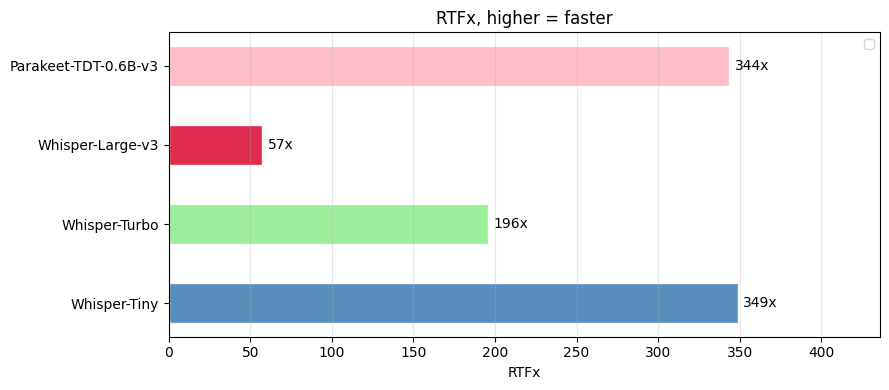

In [77]:
rtfx_models = []
rtfx_vals = []
rtfx_colors = []

for model in models_order:
    row = results_df[(results_df["model"] == model) & (results_df["dataset"] == "librispeech")]
    if len(row) and pd.notna(row["rtfx"].values[0]):
        rtfx_models.append(model)
        rtfx_vals.append(row["rtfx"].values[0])
        rtfx_colors.append(colors_map[model])

fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.barh(rtfx_models, rtfx_vals,
               color=rtfx_colors, edgecolor="white", alpha=0.9, height=0.5)
ax.bar_label(bars, fmt="%.0fx", padding=4, fontsize=10)

ax.set_title(f"RTFx, higher = faster", fontsize=12)
ax.set_xlabel("RTFx")
ax.set_xlim(0, max(rtfx_vals) * 1.25 if rtfx_vals else 10)
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "chart_rtfx.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.2 Published numbers for reference

| Model | WER EN (published) | WER RU (published) | RTFx A100 (published) |
|---|---|---|---|
| Whisper Tiny | ~6-8% (estimated) | - | - |
| Whisper Large-v3 | 6.43% | - | 68.56 |
| Whisper Turbo | 6.4% | - | 121.11 |
| Parakeet-TDT-0.6B-v3 | 6.34% | 5.51% (FLEURS) | 3332.74 |


### 8.3 Failure analysis

In [63]:
def print_failures(df, model_name, dataset_name, n=5):
    print(f"\n{model_name} | {dataset_name} | top {n} failures by WER")
    worst = df.nlargest(n, "wer")[["ref", "hyp", "wer", "duration_sec"]]
    for _, row in worst.iterrows():
        print(f"WER={row['wer']}  dur={row['duration_sec']}s")
        print(f"REF: {row['ref']}")
        print(f"HYP: {row['hyp']} \n")

In [60]:
libri_errs = [
    (df_tiny_ls, "Whisper-Tiny", "LibriSpeech"),
    (df_turbo_ls, "Whisper-Turbo", "LibriSpeech"),
    (df_large_ls, "Whisper-Large-v3", "LibriSpeech"),
    (df_par_ls, "Parakeet-TDT-0.6B-v3", "LibriSpeech"),
]
fleurs_errs = [
    (df_tiny_fl, "Whisper-Tiny", "FLEURS"),
    (df_turbo_fl, "Whisper-Turbo", "FLEURS"),
    (df_large_fl, "Whisper-Large-v3","FLEURS"),
    (df_par_fl, "Parakeet-TDT-0.6B-v3","FLEURS"),
]

In [61]:
for df_m, name, ds in libri_errs:
    if df_m is not None:
        print_failures(df_m, name, ds)
    if df_m is not None:
        print_failures(df_m, name, ds)


Whisper-Tiny | LibriSpeech | top 5 failures by WER
WER=2.6  dur=2.035s
REF: alexandra lets you sleep late
HYP: out of the way im going to show you how to make a video 

WER=2.0  dur=2.215s
REF: stephanos dedalos
HYP: steffin off dead loss 

WER=1.0  dur=1.805s
REF: hans stirs not
HYP: hawnsters nye 

WER=1.0  dur=2.44s
REF: conseil was my manservant
HYP: cause eh was my man servant 

WER=1.0  dur=1.485s
REF: verse two
HYP: 1st 2 


Whisper-Tiny | LibriSpeech | top 5 failures by WER
WER=2.6  dur=2.035s
REF: alexandra lets you sleep late
HYP: out of the way im going to show you how to make a video 

WER=2.0  dur=2.215s
REF: stephanos dedalos
HYP: steffin off dead loss 

WER=1.0  dur=1.805s
REF: hans stirs not
HYP: hawnsters nye 

WER=1.0  dur=2.44s
REF: conseil was my manservant
HYP: cause eh was my man servant 

WER=1.0  dur=1.485s
REF: verse two
HYP: 1st 2 


Whisper-Turbo | LibriSpeech | top 5 failures by WER
WER=2.6667  dur=2.435s
REF: bartley bent lower over the fire
HYP: bartley b

In [64]:
for df_m, name, ds in fleurs_errs:
    if df_m is not None:
        print_failures(df_m, name, ds)
    if df_m is not None:
        print_failures(df_m, name, ds)


Whisper-Tiny | FLEURS | top 5 failures by WER
WER=22.0  dur=12.72s
REF: дель потро имел раннее преимущество во втором сете но это также потребовало тайбрейка после достижения 66
HYP: далее подробнее я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я не знаю что я 